# Direct Gradient Inversion Without Diffusion
### (Experiment D)

This experiment tests whether the leaked gradient from the victim model is sufficient to reconstruct the target image *without using the diffusion model or GGSS-R*. The reconstruction is performed directly in image space using the usual gradient-inversion idea: start from a random image and optimize it so that its victim-model gradient becomes close to the leaked target gradient.

This experiment is placed after the two preceding diagnostics for a specific reason. The unconditional diffusion experiment showed that the isolated diffusion model can successfully denoise noise into samples on the natural image manifold. The GSS with zero guidance experiment then checked the GGSS-R/GSS sampling path with the gradient-guidance coefficient set to $m_r=0$. It showed that the GSS-conditioned pipeline can also produce meaningful face-like images when the leaked gradient is not used as guidance. Together, these results make the diffusion prior and the basic GSS sampling path less likely to be the source of the reconstruction failure observed in the full GGSS-R reproduction with $m_r=0.2$.

There is still another possible explanation: the leaked victim gradient itself may not identify the target image well enough. This experiment isolates that question by removing diffusion entirely. If direct optimization can recover the target image from the leaked gradient, then the gradient contains enough information for reconstruction, and the earlier GGSS-R failure would need to be investigated elsewhere. If direct inversion also fails, especially if images remain far from the target in pixel space even when their gradients become relatively close, this provides evidence that *gradient-space matching does not uniquely determine the target image in this setting*.

The optimization uses the exact $MLP\_1$ victim model and the same target preprocessing as the earlier experiments. The matched gradient consists of 100,000 randomly selected $fc1$ weight coordinates together with all gradients from the $fc1$ bias, $fc2$, and $fc3$, giving 166,434 matched coordinates in total. For a candidate image $x$, the objective is the normalized squared gradient difference

$$
\mathcal{L}(x) = \frac{\left\| g(x) - g_{\mathrm{target}} \right\|_2^2}{\operatorname{mean}\left(g_{\mathrm{target}}^2\right) + 10^{-12}}
$$

where $g(x)$ is the selected victim-model gradient produced by the candidate image. The candidate is parameterized as $x=\tanh(z)$, which keeps the optimized image in the model's expected \([-1,1]\) range.

A single optimization run is first used as a sanity check. The main experiment then performs eight independent random restarts with 1,500 Adam steps each. Both gradient-space metrics and pixel-space MSE are recorded. The important comparison is therefore not only whether the optimization can reduce the gradient distance, but whether doing so also produces an image that is actually close to the target.

This notebook does not constitute the gradient-identifiability diagnosis by itself; that analysis is performed in the following `gradient_identifiability_diagnosis` notebook. 

This experiment is a direct reconstruction test that provides an independent piece of evidence for that later diagnosis. It asks whether ordinary gradient inversion can recover the target from the same leaked gradient when the diffusion machinery is completely removed.

## CELL 0: Experiment Setup and Isolation

This cell creates a standalone new directory, defines the paths for output and log-keeping, and imports the libraries needed for direct gradient inversion. 

It keeps the earlier GGSS-R reproduction experiment strictly read-only. The victim checkpoint, target image, and optional target metadata are only referenced from it. All outputs of this experiment are written to a new directory. The separation is important because this notebook is intended to answer a diagnostic question independently of the diffusion experiments. No diffusion repository, diffusion checkpoint, or GGSS-R implementation is loaded here.

In [ ]:
# ============================================================
# EXPERIMENT D
# DIRECT VICTIM-GRADIENT INVERSION
#
# NO DIFFUSION
# NO GGSS-R
#
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import os
import sys
import json
import random
import time
import math

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from PIL import Image
from torchvision import transforms

# ------------------------------------------------------------
# EXISTING EXPERIMENT — READ ONLY
# ------------------------------------------------------------

EXISTING_ROOT = Path(
    "/content/drive/MyDrive/"
    "GGSS_R_unperturbed_reproduction"
).resolve()

EXISTING_VICTIM = (
    EXISTING_ROOT /
    "model_state" /
    "MLP_1.pth"
)

EXISTING_TARGET = (
    EXISTING_ROOT /
    "data" /
    "samples" /
    "celeba_target" /
    "target_0000.png"
)

EXISTING_METADATA = (
    EXISTING_ROOT /
    "data" /
    "target_metadata.pt"
)

# ------------------------------------------------------------
# COMPLETELY NEW EXPERIMENT-D DIRECTORY
# ------------------------------------------------------------

EXPERIMENT_ROOT = Path(
    "/content/drive/MyDrive/"
    "GGSS_R_experiment_D_direct_gradient_inversion"
).resolve()

INPUT_ROOT = EXPERIMENT_ROOT / "input"
OUTPUT_ROOT = EXPERIMENT_ROOT / "output"
LOG_ROOT = EXPERIMENT_ROOT / "logs"

for p in [
    INPUT_ROOT,
    OUTPUT_ROOT,
    LOG_ROOT,
]:
    p.mkdir(
        parents=True,
        exist_ok=True,
    )

print("=" * 72)
print("EXPERIMENT D — DIRECT GRADIENT INVERSION")
print("=" * 72)

print()
print("Existing source:")
print(" ", EXISTING_ROOT)

print()
print("New experiment:")
print(" ", EXPERIMENT_ROOT)

print()
print("Outputs:")
print(" ", OUTPUT_ROOT)

Mounted at /content/drive
EXPERIMENT D — DIRECT GRADIENT INVERSION

Existing source:
  /content/drive/MyDrive/GGSS_R_unperturbed_reproduction

New experiment:
  /content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion

Outputs:
  /content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion/output


## CELL 1: Verify the Existing Inputs

Before copying anything into the new experiment directory, this cell verifies that the required source files from the earlier GGSS-R experiment actually exist.

The victim checkpoint and target image are mandatory because the direct inversion attack needs the exact victim model and the exact target whose leaked gradient is being inverted. The target metadata is optional.

No diffusion checkpoint and no author repository are required. That is because the reconstruction path being tested here is purely a victim-gradient inversion procedure, with no diffusion prior involved.

In [ ]:
# ============================================================
# CELL 1 — VERIFY EXISTING INPUTS
# ============================================================

assert EXISTING_VICTIM.is_file(), (
    f"Missing victim checkpoint:\n{EXISTING_VICTIM}"
)

assert EXISTING_TARGET.is_file(), (
    f"Missing target image:\n{EXISTING_TARGET}"
)

print("=" * 72)
print("REQUIRED INPUTS")
print("=" * 72)

print()
print("✓ Victim checkpoint:")
print(" ", EXISTING_VICTIM)

print()
print("✓ Target image:")
print(" ", EXISTING_TARGET)

if EXISTING_METADATA.is_file():
    print()
    print("✓ Target metadata:")
    print(" ", EXISTING_METADATA)
else:
    print()
    print("ℹ Target metadata not found.")
    print("  This is optional.")

print()
print("No diffusion checkpoint is required.")
print("No repository is required.")

REQUIRED INPUTS

✓ Victim checkpoint:
  /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/model_state/MLP_1.pth

✓ Target image:
  /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/data/samples/celeba_target/target_0000.png

✓ Target metadata:
  /content/drive/MyDrive/GGSS_R_unperturbed_reproduction/data/target_metadata.pt

No diffusion checkpoint is required.
No repository is required.


### Result

All the required inputs are present. The experiment can now be executed in isolation.

## CELL 2: Copy the Inputs Into the Isolated Experiment

This cell copies the verified victim checkpoint, target image, and optional target metadata into the new Experiment-D directory.

The original files are never modified. Keeping local copies inside the experiment makes the run self-contained and preserves a clear record of exactly which inputs were used. 

In [ ]:
# ============================================================
# CELL 2 — COPY INPUTS
#
# The original files are NEVER modified.
# ============================================================

VICTIM_DIR = INPUT_ROOT / "victim_model"
TARGET_DIR = INPUT_ROOT / "target"

VICTIM_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

TARGET_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

VICTIM_CHECKPOINT = (
    VICTIM_DIR / "MLP_1.pth"
)

TARGET_PATH = (
    TARGET_DIR / "target_0000.png"
)

shutil.copy2(
    EXISTING_VICTIM,
    VICTIM_CHECKPOINT,
)

shutil.copy2(
    EXISTING_TARGET,
    TARGET_PATH,
)

TARGET_METADATA_COPY = None

if EXISTING_METADATA.is_file():

    TARGET_METADATA_COPY = (
        TARGET_DIR / "target_metadata.pt"
    )

    shutil.copy2(
        EXISTING_METADATA,
        TARGET_METADATA_COPY,
    )

print("=" * 72)
print("EXPERIMENT D INPUT COPIES")
print("=" * 72)

print()
print("Victim:")
print(" ", VICTIM_CHECKPOINT)

print()
print("Target:")
print(" ", TARGET_PATH)

if TARGET_METADATA_COPY:
    print()
    print("Metadata:")
    print(" ", TARGET_METADATA_COPY)

print()
print("✓ Existing experiment remains untouched.")

EXPERIMENT D INPUT COPIES

Victim:
  /content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion/input/victim_model/MLP_1.pth

Target:
  /content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion/input/target/target_0000.png

Metadata:
  /content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion/input/target/target_metadata.pt

✓ Existing experiment remains untouched.


### Result

The inputs are copied into the local self-contained directory.

## CELL 3: Define the Direct Inversion Configuration

This cell fixes the experimental parameters for the direct gradient inversion attack and seeds the random number generators.

The main experiment uses 8 random restarts, with each restart optimized for 1,500 Adam steps at a learning rate of 0.05. Only 100,000 randomly selected coordinates from the very large $fc1$ weight gradient are matched, while the complete gradients of the remaining layers and the fc1 bias are included. The target class is fixed to class 0, matching the victim-model setup used in the earlier experiments.

Multiple random restarts are important because direct gradient inversion is a non-convex optimization problem. A single initialization could fail simply because the optimizer reaches an unfavorable solution. Running eight independently initialized reconstructions lets us check whether the observed behavior is consistent across different starting points.

The random seed is fixed for reproducibility, while the individual restart seeds are derived from it later so that each restart is deterministic but different from the others.

In [ ]:
# ============================================================
# CELL 3 — EXPERIMENT CONFIGURATION
# ============================================================

SEED = 2026

N_RESTARTS = 8

N_STEPS = 1500

LEARNING_RATE = 0.05

# Number of randomly selected fc1 weight coordinates.
N_FC1_RANDOM = 100_000

SAVE_EVERY = 100

TARGET_CLASS = 0

DEVICE = torch.device(
    "cuda:0"
    if torch.cuda.is_available()
    else "cpu"
)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("=" * 72)
print("EXPERIMENT D CONFIGURATION")
print("=" * 72)

print()
print("Random restarts :", N_RESTARTS)
print("Optimization steps:", N_STEPS)
print("Learning rate   :", LEARNING_RATE)
print("Gradient coords :", N_FC1_RANDOM)
print("Target class    :", TARGET_CLASS)
print("Device          :", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

EXPERIMENT D CONFIGURATION

Random restarts : 8
Optimization steps: 1500
Learning rate   : 0.05
Gradient coords : 100000
Target class    : 0
Device          : cuda:0
GPU: Tesla T4


### Result

The configs are set as 8 independent random restarts, 1500 optimization steps per restart, learning rate \(0.05\), and 100K selected `fc1` weight-gradient coordinates.

## CELL 4: Reconstruct the Exact Victim Model

This cell recreates the exact `MLP_1` architecture used to produce the leaked gradient and loads its saved checkpoint.

The architecture takes a normalized $3\times256\times256$ image, flattens it into 196,608 inputs, and passes it through three fully connected layers:

$$
196608 \rightarrow 512 \rightarrow 128 \rightarrow 2,
$$

with ReLU activations after the first two layers. The model is loaded with strict=True, so the checkpoint must match the recreated architecture.

Verifying the total parameter count is an additional consistency check. Direct gradient inversion is highly sensitive to the exact victim model because the target gradient is defined by this model's parameters and forward computation. Using even a slightly different architecture would make the gradient-matching problem a different experiment.

In [ ]:
# ============================================================
# CELL 4 — EXACT MLP_1 ARCHITECTURE
# ============================================================

class MLP_1(nn.Module):

    def __init__(self):

        super().__init__()

        self.fc1 = nn.Linear(
            3 * 256 * 256,
            512,
        )

        self.fc2 = nn.Linear(
            512,
            128,
        )

        self.fc3 = nn.Linear(
            128,
            2,
        )

        self.relu = nn.ReLU()

    def forward(self, x):

        x = x.view(
            x.size(0),
            -1,
        )

        x = self.relu(
            self.fc1(x)
        )

        x = self.relu(
            self.fc2(x)
        )

        x = self.fc3(x)

        return x


model = MLP_1().to(DEVICE)

checkpoint = torch.load(
    VICTIM_CHECKPOINT,
    map_location=DEVICE,
    weights_only=False,
)

if isinstance(checkpoint, dict):

    if "state_dict" in checkpoint:
        state_dict = checkpoint["state_dict"]

    elif "model_state_dict" in checkpoint:
        state_dict = checkpoint["model_state_dict"]

    else:
        state_dict = checkpoint

else:

    state_dict = checkpoint

state_dict = {
    k.replace("module.", "", 1): v
    for k, v in state_dict.items()
}

model.load_state_dict(
    state_dict,
    strict=True,
)

model.eval()

NUM_PARAMS = sum(
    p.numel()
    for p in model.parameters()
)

print("=" * 72)
print("VICTIM MODEL")
print("=" * 72)

print(model)

print()
print("Total parameters:", NUM_PARAMS)

assert NUM_PARAMS == 100_729_730

print()
print("✓ Exact MLP_1 parameter count verified.")

VICTIM MODEL
MLP_1(
  (fc1): Linear(in_features=196608, out_features=512, bias=True)
  (fc2): Linear(in_features=512, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=2, bias=True)
  (relu): ReLU()
)

Total parameters: 100729730

✓ Exact MLP_1 parameter count verified.


### Result

The loaded model is the expected `MLP_1` architecture, with a total of 100,729,730 parameters. The explicit parameter-count assertion passes.

## CELL 5: Preprocess the Target and Verify Its Victim Prediction

This cell loads the target image and applies the same preprocessing expected by the victim model. That is, resize to $256 \times 256$, convert to a tensor, and normalize each RGB channel from \([0,1]\) to \([-1,1]\).

The cell then passes the target through the victim model and records its logits, class probabilities, and predicted class. The prediction is required to be class 0 because the gradient calculation later assumes the class-0 cross-entropy objective.

This check matters because the leaked gradient is not just a property of the image. It depends on the loss being differentiated. We therefore verify that the target, preprocessing, victim checkpoint, and assumed target class are consistent before constructing the target gradient.

In [ ]:
# ============================================================
# CELL 5 — TARGET PREPROCESSING
# ============================================================

TRANSFORM = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(
        (0.5, 0.5, 0.5),
        (0.5, 0.5, 0.5),
    ),
])

target_pil = Image.open(
    TARGET_PATH
).convert("RGB")

target = TRANSFORM(
    target_pil
).unsqueeze(0).to(DEVICE)

print("=" * 72)
print("TARGET")
print("=" * 72)

print()
print("Target shape:", tuple(target.shape))
print("Range:",
      float(target.min()),
      "to",
      float(target.max()))

# ------------------------------------------------------------
# Target victim prediction
# ------------------------------------------------------------

with torch.no_grad():

    target_logits = model(target)

    target_probs = torch.softmax(
        target_logits,
        dim=1,
    )

    target_prediction = int(
        target_logits.argmax(dim=1).item()
    )

print()
print("Target logits:")
print(target_logits.detach().cpu().numpy())

print()
print("Target probabilities:")
print(target_probs.detach().cpu().numpy())

print()
print("Victim prediction:", target_prediction)

assert target_prediction == TARGET_CLASS

print()
print("✓ Target is classified as class 0.")

TARGET

Target shape: (1, 3, 256, 256)
Range: -1.0 to 1.0

Target logits:
[[-0.10914069 -4.377861  ]]

Target probabilities:
[[0.9861936 0.0138064]]

Victim prediction: 0

✓ Target is classified as class 0.


### Result

The target is converted to a $1\times3\times256\times256$ tensor in the expected $[-1,1]$ range. The victim assigns it a class-0 probability of approximately \(0.9862\), with class 0 selected as the prediction.

The class check passes, so the cross-entropy gradient used throughout the experiment is consistent with the target's actual victim-model prediction and the configured target class.

## CELL 6: Select the Gradient Coordinates to Match

The victim's first fully connected layer contains over 100 million weight parameters, so matching every coordinate would be unnecessarily expensive for this diagnostic. This cell therefore selects 100,000 `fc1` weight coordinates using a reproducible random selection.

All 512 `fc1` bias coordinates and all parameters in `fc2` and `fc3` are also included. The resulting matched gradient has 166,434 coordinates:

$$
100000
+512
+65664
+258
=166434.
$$

The selected indices are sorted and stored so that the same coordinates are used consistently when computing both the target gradient and every candidate gradient.

The purpose is to reproduce a manageable but structured version of the leaked gradient used by the experiment, while keeping the exact same coordinate definition throughout the optimization.

In [ ]:
# ============================================================
# CELL 6 — GRADIENT SUBSET
# ============================================================

FC1_WEIGHT_N = model.fc1.weight.numel()

rng = np.random.default_rng(
    SEED
)

fc1_indices = np.sort(
    rng.choice(
        FC1_WEIGHT_N,
        size=N_FC1_RANDOM,
        replace=False,
    )
)

fc1_indices_t = torch.tensor(
    fc1_indices,
    dtype=torch.long,
    device=DEVICE,
)

print("=" * 72)
print("GRADIENT MATCHING SUBSET")
print("=" * 72)

print()
print("fc1 weight parameters:",
      FC1_WEIGHT_N)

print(
    "Selected fc1 weights:",
    len(fc1_indices)
)

print(
    "fc1 bias:",
    model.fc1.bias.numel()
)

print(
    "fc2:",
    model.fc2.weight.numel()
    + model.fc2.bias.numel()
)

print(
    "fc3:",
    model.fc3.weight.numel()
    + model.fc3.bias.numel()
)

TOTAL_MATCHED = (
    N_FC1_RANDOM
    + model.fc1.bias.numel()
    + model.fc2.weight.numel()
    + model.fc2.bias.numel()
    + model.fc3.weight.numel()
    + model.fc3.bias.numel()
)

print()
print(
    "Total matched gradient coordinates:",
    TOTAL_MATCHED
)

GRADIENT MATCHING SUBSET

fc1 weight parameters: 100663296
Selected fc1 weights: 100000
fc1 bias: 512
fc2: 65664
fc3: 258

Total matched gradient coordinates: 166434


### Result

The attack matches 166,434 gradient coordinates in total: 100,000 randomly selected `fc1` weight coordinates, all 512 `fc1` bias coordinates, all 65,664 `fc2` coordinates, and all 258 `fc3` coordinates.

This is the exact gradient vector that the direct inversion objective will attempt to reproduce for every candidate image.

## CELL 7: Implement the Victim Gradient Analytically

This cell defines `selected_gradient(image)`, which computes the exact gradient coordinates used by the direct inversion attack.

The function explicitly performs the victim forward pass,

$$
x \rightarrow z_1 \rightarrow a_1 \rightarrow z_2
\rightarrow a_2 \rightarrow \text{logits},
$$

and then derives the cross-entropy gradient analytically. For class 0, the output-layer error is

$$
\delta_3 = p-y,
$$

where \(p\) is the softmax probability vector and \(y\) is the one-hot class-0 target. The error is then propagated through the linear layers and ReLU gates to obtain the gradients of \(fc3\), \(fc2\), \(fc1\), and the corresponding biases.

Only the selected 100,000 `fc1` weight coordinates are retained, while the other specified gradient tensors are kept in full.

This analytical implementation is useful because the candidate/ predicted/ reconstructed image will itself be optimized through the gradient-matching objective. The returned victim gradients therefore need to remain differentiable with respect to the input image, so that the optimizer can update the image through the gradient-matching loss.

In [ ]:
# ============================================================
# CELL 7 — ANALYTIC VICTIM GRADIENT
# ============================================================

def selected_gradient(image):

    """
    Compute the exact selected victim-gradient coordinates
    for the authors' MLP_1 and class-0 cross entropy.

    No diffusion is involved.
    """

    # --------------------------------------------------------
    # Forward pass
    # --------------------------------------------------------

    x = image.view(
        image.shape[0],
        -1,
    )

    z1 = model.fc1(x)
    a1 = torch.relu(z1)

    z2 = model.fc2(a1)
    a2 = torch.relu(z2)

    logits = model.fc3(a2)

    # --------------------------------------------------------
    # Cross entropy derivative
    # --------------------------------------------------------

    probabilities = torch.softmax(
        logits,
        dim=1,
    )

    target_onehot = torch.zeros_like(
        probabilities
    )

    target_onehot[:, TARGET_CLASS] = 1.0

    delta3 = (
        probabilities
        - target_onehot
    )

    # --------------------------------------------------------
    # fc3 gradients
    #
    # dL/dW3 = delta3^T @ a2
    # --------------------------------------------------------

    grad_fc3_weight = (
        delta3.T @ a2
    ).reshape(-1)

    grad_fc3_bias = (
        delta3.reshape(-1)
    )

    # --------------------------------------------------------
    # Backprop through fc3 and ReLU
    # --------------------------------------------------------

    da2 = (
        delta3
        @ model.fc3.weight
    )

    delta2 = (
        da2
        * (z2 > 0).to(da2.dtype)
    )

    # --------------------------------------------------------
    # fc2 gradients
    # --------------------------------------------------------

    grad_fc2_weight = (
        delta2.T @ a1
    ).reshape(-1)

    grad_fc2_bias = (
        delta2.reshape(-1)
    )

    # --------------------------------------------------------
    # Backprop through fc2 and ReLU
    # --------------------------------------------------------

    da1 = (
        delta2
        @ model.fc2.weight
    )

    delta1 = (
        da1
        * (z1 > 0).to(da1.dtype)
    )

    # --------------------------------------------------------
    # fc1 gradients
    # --------------------------------------------------------

    grad_fc1_weight_flat = (
        delta1.T @ x
    ).reshape(-1)

    selected_fc1_weight = (
        grad_fc1_weight_flat[
            fc1_indices_t
        ]
    )

    grad_fc1_bias = (
        delta1.reshape(-1)
    )

    # --------------------------------------------------------
    # Concatenate the EXACT selected gradient
    # --------------------------------------------------------

    selected = torch.cat([
        selected_fc1_weight,
        grad_fc1_bias,
        grad_fc2_weight,
        grad_fc2_bias,
        grad_fc3_weight,
        grad_fc3_bias,
    ])

    return selected, logits


print("✓ Analytic gradient function defined.")

✓ Analytic gradient function defined.


## CELL 8: Verify the Analytical Gradient Against Autograd

Before using the analytical gradient inside an optimization loop, this cell checks it against a direct PyTorch autograd calculation on the target image.

Both methods compute the same six gradient components: the selected `fc1` weights, the complete `fc1` bias, `fc2` weights and bias, and `fc3` weights and bias. The analytical result and autograd result are then compared using maximum absolute error and relative error.

This is an important implementation sanity check. If the analytical gradient were even slightly wrong, the subsequent inversion could appear to fail. That's because the optimizer would be matching the target against an incorrectly computed candidate gradient. 

A zero error here means the gradient function used by the attack is consistent with the victim model's actual cross-entropy gradient.

In [ ]:
# ============================================================
# CELL 8 — GRADIENT IMPLEMENTATION CHECK
# ============================================================

torch.manual_seed(SEED)

test_x = target.detach().clone()
test_x.requires_grad_(True)

# ------------------------------------------------------------
# Analytic
# ------------------------------------------------------------

analytic_grad, analytic_logits = (
    selected_gradient(test_x)
)

# ------------------------------------------------------------
# Autograd
# ------------------------------------------------------------

model.zero_grad(
    set_to_none=True
)

logits = model(test_x)

loss = nn.CrossEntropyLoss()(
    logits,
    torch.tensor(
        [TARGET_CLASS],
        device=DEVICE,
    ),
)

autograd_grads = torch.autograd.grad(
    loss,
    [
        model.fc1.weight,
        model.fc1.bias,
        model.fc2.weight,
        model.fc2.bias,
        model.fc3.weight,
        model.fc3.bias,
    ],
    retain_graph=False,
    create_graph=False,
)

autograd_fc1 = (
    autograd_grads[0]
    .reshape(-1)[fc1_indices_t]
)

autograd_selected = torch.cat([
    autograd_fc1,
    autograd_grads[1].reshape(-1),
    autograd_grads[2].reshape(-1),
    autograd_grads[3].reshape(-1),
    autograd_grads[4].reshape(-1),
    autograd_grads[5].reshape(-1),
])

max_error = (
    analytic_grad
    - autograd_selected
).abs().max().item()

relative_error = (
    torch.linalg.vector_norm(
        analytic_grad
        - autograd_selected
    )
    /
    (
        torch.linalg.vector_norm(
            autograd_selected
        )
        + 1e-12
    )
).item()

print("=" * 72)
print("GRADIENT IMPLEMENTATION CHECK")
print("=" * 72)

print()
print("Maximum absolute error :", max_error)
print("Relative error         :", relative_error)

assert relative_error < 1e-5

print()
print("✓ Analytic gradient matches PyTorch autograd.")

GRADIENT IMPLEMENTATION CHECK

Maximum absolute error : 0.0
Relative error         : 0.0

✓ Analytic gradient matches PyTorch autograd.


### Result

The analytical gradient implementation matches PyTorch autograd exactly on the target image:

- maximum absolute error: `0.0`
- relative error: `0.0`

This removes a major implementation concern before the inversion begins. 

## CELL 9: Compute and Record the Target Gradient

This cell evaluates the analytical gradient function on the actual target image, and stores the resulting 166,434-dimensional vector as the reference gradient for the entire experiment.

Two quantities are recorded for normalization:

$$
\|g_{\mathrm{target}}\|_2
$$

and

$$
\operatorname{mean}(g_{\mathrm{target}}^2).
$$

The latter is used in the normalized gradient-matching loss, while the former is used to report relative gradient distance.

The finiteness check ensures that the reference gradient contains no NaNs or infinities before optimization begins. From this point onward, every candidate image is evaluated by comparing its selected victim gradient against this fixed target gradient.

In [ ]:
# ============================================================
# CELL 9 — TARGET GRADIENT
# ============================================================

with torch.no_grad():

    target_gradient, _ = (
        selected_gradient(
            target
        )
    )

target_gradient = (
    target_gradient.detach()
)

TARGET_GRAD_NORM = (
    torch.linalg.vector_norm(
        target_gradient
    )
)

TARGET_GRAD_MEAN_SQ = (
    torch.mean(
        target_gradient ** 2
    )
)

print("=" * 72)
print("TARGET GRADIENT")
print("=" * 72)

print()
print(
    "Matched coordinates:",
    target_gradient.numel()
)

print(
    "Target gradient norm:",
    float(TARGET_GRAD_NORM)
)

print(
    "Target gradient mean square:",
    float(TARGET_GRAD_MEAN_SQ)
)

assert torch.isfinite(
    target_gradient
).all()

print()
print("✓ Target gradient is finite.")

TARGET GRADIENT

Matched coordinates: 166434
Target gradient norm: 1.3281235694885254
Target gradient mean square: 1.0598269000183791e-05

✓ Target gradient is finite.


### Result

The target gradient contains 166K finite coordinates, with an $L_2$ norm of approximately $1.3281$ and a mean squared value of approximately $1.0598\times10^{-5}$.

These values establish the scale used by the normalized gradient-matching objective (mean squared value) and the relative-distance metric (L2 norm). The finite-value check also confirms that the reference gradient is numerically valid.

## CELL 10: Define Gradient-Space and Image-Space Metrics

This cell defines the metrics used to judge the reconstruction from two different perspectives.

For gradient-space matching, it computes:

- the Euclidean gradient distance, i.e. the total absolute difference in both magnitude and direction between two gradients,
  $$
  \|g(x)-g_{\mathrm{target}}\|_2,
  $$
- the relative gradient distance, i.e. the magnitude of the gradient difference as a fraction of the target gradient's scale,
  $$
  \frac{\|g(x)-g_{\mathrm{target}}\|_2}
  {\|g_{\mathrm{target}}\|_2+10^{-12}},
  $$
- gradient cosine similarity, i.e. the pure directional alignment between gradients that completely ignores their magnitudes,
$$
\frac{g(x) \cdot g_{\mathrm{target}}}{\|g(x)\|_2 \|g_{\mathrm{target}}\|_2}
$$
- and normalized gradient MSE, i.e., the average squared dissimilarity between the direction-only unit vectors per parameter,
$$
\operatorname{mean}\left[ \left( \frac{g(x)}{\|g(x)\|_2} - \frac{g_{\mathrm{target}}}{\|g_{\mathrm{target}}\|_2} \right)^2 \right]
$$

It also defines pixel-space MSE,

$$
\operatorname{MSE}_{\mathrm{image}}(x,x_{\mathrm{target}})
=
\operatorname{mean}\left[(x-x_{\mathrm{target}})^2\right].
$$

The separation between these two spaces is central to Experiment D. A candidate can become much closer to the leaked gradient without necessarily becoming close to the target image itself. Recording both sets of metrics allows the experiment to test precisely whether gradient matching translates into actual image reconstruction.

In [ ]:
# ============================================================
# CELL 10 — METRICS
# ============================================================

def gradient_metrics(
    candidate_gradient,
):

    diff = (
        candidate_gradient
        - target_gradient
    )

    distance = (
        torch.linalg.vector_norm(
            diff
        )
    )

    relative_distance = (
        distance
        /
        (
            TARGET_GRAD_NORM
            + 1e-12
        )
    )

    cosine = (
        torch.dot(
            candidate_gradient,
            target_gradient,
        )
        /
        (
            torch.linalg.vector_norm(
                candidate_gradient
            )
            *
            TARGET_GRAD_NORM
            + 1e-12
        )
    )

    normalized_mse = torch.mean(
        diff ** 2
    ) / (
        TARGET_GRAD_MEAN_SQ
        + 1e-12
    )

    return {
        "gradient_distance":
            float(distance.detach()),

        "relative_gradient_distance":
            float(relative_distance.detach()),

        "gradient_cosine":
            float(cosine.detach()),

        "normalized_gradient_mse":
            float(normalized_mse.detach()),
    }


def image_metrics(
    candidate,
):

    mse = torch.mean(
        (
            candidate
            - target
        ) ** 2
    )

    return {
        "pixel_mse":
            float(mse.detach()),
    }


print("✓ Metrics defined.")

✓ Metrics defined.


## CELL 11: Run a Single Direct Gradient-Inversion Test

This cell performs one complete direct inversion run before launching the eight-restart experiment.

The candidate image is not initialized as a normal image and optimized directly with pixel values. Instead, a free parameter $z$ is initialized from Gaussian noise and converted to an image through

$$
x=\tanh(z),
$$

which guarantees that every candidate remains in the victim model's expected $[-1,1]$ input range.

At each optimization step, the candidate gradient $g(x)$ is computed, and Adam minimizes the normalized squared difference between that gradient and the fixed target gradient:

$$
\mathcal{L}(x)
=
\frac{\operatorname{mean}\left[(g(x)-g_{\mathrm{target}})^2\right]}
{\operatorname{mean}(g_{\mathrm{target}}^2)+10^{-12}}.
$$

Every 100 steps, both gradient-space metrics and pixel-space MSE are recorded. The final candidate image and the metric history are saved to the test-run directory.

This first run serves two purposes. First, it confirms that the direct inversion procedure actually optimizes as intended. Second, it shows whether reducing the gradient mismatch produces a corresponding reduction in pixel-space error, before the experiment is repeated across multiple random initializations.

In [ ]:
# ============================================================
# CELL 11 — SINGLE TEST INVERSION
# ============================================================

TEST_OUTPUT = (
    OUTPUT_ROOT /
    "test_run"
)

TEST_OUTPUT.mkdir(
    parents=True,
    exist_ok=True,
)

torch.manual_seed(
    SEED
)

# ------------------------------------------------------------
# Random image parameterization
#
# x = tanh(z), guaranteeing [-1,1].
# ------------------------------------------------------------

z = (
    torch.randn(
        (1, 3, 256, 256),
        device=DEVICE,
    )
    * 1.0
).requires_grad_(True)

optimizer = torch.optim.Adam(
    [z],
    lr=LEARNING_RATE,
)

test_rows = []

start_time = time.time()

for step in range(
    N_STEPS
):

    optimizer.zero_grad(
        set_to_none=True
    )

    candidate = torch.tanh(z)

    candidate_gradient, logits = (
        selected_gradient(
            candidate
        )
    )

    diff = (
        candidate_gradient
        - target_gradient
    )

    loss = torch.mean(
        diff ** 2
    ) / (
        TARGET_GRAD_MEAN_SQ
        + 1e-12
    )

    loss.backward()

    optimizer.step()

    if (
        step % SAVE_EVERY == 0
        or step == N_STEPS - 1
    ):

        gm = gradient_metrics(
            candidate_gradient
        )

        im = image_metrics(
            candidate
        )

        row = {
            "step": step,
            "loss": float(loss.detach()),
            **gm,
            **im,
        }

        test_rows.append(row)

        print(
            f"step={step:4d} "
            f"loss={row['loss']:.6e} "
            f"rel_grad_dist={row['relative_gradient_distance']:.6f} "
            f"cos={row['gradient_cosine']:.6f} "
            f"pixel_mse={row['pixel_mse']:.6f}"
        )

elapsed = (
    time.time()
    - start_time
)

print()
print(
    f"Test inversion runtime: "
    f"{elapsed / 60:.2f} minutes"
)

# ------------------------------------------------------------
# Save test image
# ------------------------------------------------------------

def save_image_tensor(
    tensor,
    path,
):

    rgb = (
        tensor.detach()
        .cpu()
        .clamp(-1, 1)
        .add(1)
        .div(2)
    )

    rgb = (
        rgb[0]
        .permute(1, 2, 0)
        .numpy()
        * 255
    ).astype(np.uint8)

    Image.fromarray(
        rgb
    ).save(path)


save_image_tensor(
    torch.tanh(z),
    TEST_OUTPUT / "final.png",
)

pd.DataFrame(
    test_rows
).to_csv(
    TEST_OUTPUT / "metrics.csv",
    index=False,
)

print()
print("Test output:")
print(
    TEST_OUTPUT / "final.png"
)

step=   0 loss=1.291124e+00 rel_grad_dist=1.136276 cos=0.403902 pixel_mse=0.668314
step= 100 loss=9.525098e-01 rel_grad_dist=0.975966 cos=0.567229 pixel_mse=0.677928
step= 200 loss=5.593477e-01 rel_grad_dist=0.747896 cos=0.664273 pixel_mse=0.666797
step= 300 loss=4.922500e-01 rel_grad_dist=0.701605 cos=0.712580 pixel_mse=0.655339
step= 400 loss=4.546350e-01 rel_grad_dist=0.674266 cos=0.738489 pixel_mse=0.647351
step= 500 loss=4.230061e-01 rel_grad_dist=0.650389 cos=0.759606 pixel_mse=0.641871
step= 600 loss=3.978827e-01 rel_grad_dist=0.630780 cos=0.775998 pixel_mse=0.637100
step= 700 loss=3.133686e-01 rel_grad_dist=0.559793 cos=0.828636 pixel_mse=0.630195
step= 800 loss=2.918647e-01 rel_grad_dist=0.540245 cos=0.841687 pixel_mse=0.624632
step= 900 loss=2.809155e-01 rel_grad_dist=0.530015 cos=0.848055 pixel_mse=0.621845
step=1000 loss=2.735567e-01 rel_grad_dist=0.523027 cos=0.852366 pixel_mse=0.620548
step=1100 loss=2.692047e-01 rel_grad_dist=0.518849 cos=0.854906 pixel_mse=0.620055
step

### Result

The single test inversion does reduce the gradient mismatch substantially over 1500 steps. The relative gradient distance falls from `1.136276` at step 0 to `0.510638` at step 1499, while cosine similarity increases from `0.403902` to `0.859811`.

However, the pixel MSE remains high: it starts at `0.668314` and ends at `0.620586`. In other words, the optimizer is making clear progress toward the target *in gradient space*, but that progress does NOT translate into a comparably strong pixel-space reconstruction.

This is an important observation for the diagnostic. It shows that the direct inversion objective is capable of changing the candidate gradient in the desired direction, so a completely flat or broken gradient optimization would not explain the reconstruction failure. At the same time, the candidate image is still far from the target under the pixel-space metric after 1,500 steps.

## CELL 12: Run Eight Independent Random Restarts

This is the main Experiment-D reconstruction loop. It repeats the same direct gradient inversion procedure eight times, changing only the random initialization of the image parameter $z$.

Each restart receives its own reproducible seed, runs for 1500 Adam steps, and records the initial and final gradient-space and pixel-space metrics. The final reconstructed image and the corresponding metric history are saved separately for every run. The results are also aggregated into `all_restart_metrics.csv` and `final_restart_summary.csv`.

The multiple restarts are important because a successful gradient match from one initialization would not by itself establish that the target image is recoverable. Conversely, if several independent runs converge toward low gradient error but remain far from the target in pixel space, that would be stronger evidence that the gradient-matching objective admits solutions that are not the target image.

The final table also records the victim-model prediction of each reconstruction. This provides a coarse semantic check, but it is not sufficient to establish image recovery: matching the target's class is much weaker than reproducing the target image itself.

In [ ]:
# ============================================================
# CELL 12 — EXPERIMENT D
# 8 RANDOM INITIALIZATIONS
# ============================================================

RUNS_ROOT = (
    OUTPUT_ROOT /
    "eight_random_restarts"
)

RUNS_ROOT.mkdir(
    parents=True,
    exist_ok=True,
)

all_rows = []
final_rows = []

print("=" * 72)
print("EXPERIMENT D — 8 RANDOM INITIALIZATIONS")
print("=" * 72)

experiment_start = time.time()

for run_id in range(
    N_RESTARTS
):

    print()
    print(
        "=" * 72
    )

    print(
        f"STARTING RUN {run_id + 1}/{N_RESTARTS}"
    )

    print(
        "=" * 72
    )

    run_dir = (
        RUNS_ROOT /
        f"run_{run_id:02d}"
    )

    run_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    # --------------------------------------------------------
    # Reproducible but different initialization
    # --------------------------------------------------------

    run_seed = (
        SEED
        + 1000
        + run_id
    )

    torch.manual_seed(
        run_seed
    )

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(
            run_seed
        )

    z = (
        torch.randn(
            (1, 3, 256, 256),
            device=DEVICE,
        )
        * 1.0
    ).requires_grad_(True)

    optimizer = torch.optim.Adam(
        [z],
        lr=LEARNING_RATE,
    )

    rows = []

    run_start = time.time()

    for step in range(
        N_STEPS
    ):

        optimizer.zero_grad(
            set_to_none=True
        )

        candidate = torch.tanh(z)

        candidate_gradient, logits = (
            selected_gradient(
                candidate
            )
        )

        diff = (
            candidate_gradient
            - target_gradient
        )

        loss = torch.mean(
            diff ** 2
        ) / (
            TARGET_GRAD_MEAN_SQ
            + 1e-12
        )

        loss.backward()

        optimizer.step()

        if (
            step % SAVE_EVERY == 0
            or step == N_STEPS - 1
        ):

            gm = gradient_metrics(
                candidate_gradient
            )

            im = image_metrics(
                candidate
            )

            prediction = int(
                logits.argmax(
                    dim=1
                ).item()
            )

            row = {
                "run":
                    run_id,

                "step":
                    step,

                "seed":
                    run_seed,

                "loss":
                    float(
                        loss.detach()
                    ),

                "victim_prediction":
                    prediction,

                **gm,
                **im,
            }

            rows.append(
                row
            )

            all_rows.append(
                row
            )

            if (
                step == 0
                or step == N_STEPS - 1
            ):

                print(
                    f"run={run_id:02d} "
                    f"step={step:4d} "
                    f"rel_dist="
                    f"{row['relative_gradient_distance']:.6f} "
                    f"cos="
                    f"{row['gradient_cosine']:.6f} "
                    f"MSE="
                    f"{row['pixel_mse']:.6f}"
                )

    run_elapsed = (
        time.time()
        - run_start
    )

    # --------------------------------------------------------
    # Final image
    # --------------------------------------------------------

    final_image = torch.tanh(z)

    save_image_tensor(
        final_image,
        run_dir / "final.png",
    )

    # --------------------------------------------------------
    # Initial image
    # --------------------------------------------------------

    # Reconstruct the same initial state for documentation.
    torch.manual_seed(
        run_seed
    )

    initial_z = (
        torch.randn(
            (1, 3, 256, 256),
            device=DEVICE,
        )
    )

    initial_image = torch.tanh(
        initial_z
    )

    save_image_tensor(
        initial_image,
        run_dir / "initial.png",
    )

    # --------------------------------------------------------
    # Save metrics
    # --------------------------------------------------------

    pd.DataFrame(
        rows
    ).to_csv(
        run_dir / "metrics.csv",
        index=False,
    )

    final = rows[-1]

    final_rows.append({
        "run":
            run_id,

        "seed":
            run_seed,

        "runtime_minutes":
            run_elapsed / 60,

        "final_loss":
            final["loss"],

        "final_gradient_distance":
            final["gradient_distance"],

        "final_relative_gradient_distance":
            final[
                "relative_gradient_distance"
            ],

        "final_gradient_cosine":
            final[
                "gradient_cosine"
            ],

        "final_pixel_mse":
            final[
                "pixel_mse"
            ],

        "final_victim_prediction":
            final[
                "victim_prediction"
            ],
    })

    print()
    print(
        f"Run {run_id} completed "
        f"in {run_elapsed / 60:.2f} min"
    )

# ------------------------------------------------------------
# Save combined results
# ------------------------------------------------------------

all_df = pd.DataFrame(
    all_rows
)

final_df = pd.DataFrame(
    final_rows
)

all_df.to_csv(
    OUTPUT_ROOT /
    "all_restart_metrics.csv",
    index=False,
)

final_df.to_csv(
    OUTPUT_ROOT /
    "final_restart_summary.csv",
    index=False,
)

total_elapsed = (
    time.time()
    - experiment_start
)

print()
print("=" * 72)
print("EXPERIMENT D COMPLETE")
print("=" * 72)

print()
print(
    f"Total runtime: "
    f"{total_elapsed / 60:.2f} minutes"
)

print()
print(final_df)

EXPERIMENT D — 8 RANDOM INITIALIZATIONS

STARTING RUN 1/8
run=00 step=   0 rel_dist=2.245078 cos=0.217842 MSE=0.670464
run=00 step=1499 rel_dist=0.282238 cos=0.959350 MSE=0.458092

Run 0 completed in 0.44 min

STARTING RUN 2/8
run=01 step=   0 rel_dist=2.625093 cos=0.247119 MSE=0.673366
run=01 step=1499 rel_dist=0.284004 cos=0.958823 MSE=0.462779

Run 1 completed in 0.44 min

STARTING RUN 3/8
run=02 step=   0 rel_dist=1.206122 cos=0.300470 MSE=0.669774
run=02 step=1499 rel_dist=0.529913 cos=0.848094 MSE=0.633152

Run 2 completed in 0.44 min

STARTING RUN 4/8
run=03 step=   0 rel_dist=1.179049 cos=0.427856 MSE=0.668388
run=03 step=1499 rel_dist=0.505246 cos=0.863003 MSE=0.621771

Run 3 completed in 0.44 min

STARTING RUN 5/8
run=04 step=   0 rel_dist=1.524147 cos=0.194938 MSE=0.669509
run=04 step=1499 rel_dist=0.041214 cos=0.999151 MSE=0.431139

Run 4 completed in 0.44 min

STARTING RUN 6/8
run=05 step=   0 rel_dist=2.388054 cos=0.111640 MSE=0.668188
run=05 step=1499 rel_dist=0.280120 c

### Result

The eight independent restarts show the same general separation between gradient-space matching and pixel-space reconstruction, although the degree of gradient matching varies substantially across initializations.

The strongest gradient matches are runs 4 and 7, with relative gradient distances of `0.041214` and `0.043318` and cosine similarities of `0.999151` and `0.999062`, respectively. These are very strong gradient-space matches. Yet their pixel MSEs remain `0.431139` and `0.451568`, which are still substantial.

Other runs also reduce the gradient distance considerably but stop farther away in gradient space: for example, runs 0, 1, and 5 end around `0.28` relative distance, while runs 2, 3, and 6 remain around `0.48–0.53`. 

Importantly, none of the eight runs produces a reconstruction with low pixel MSE comparable to what would be expected from actual recovery of the target image.

All eight final reconstructions are classified as class 0 by the victim model. This shows that the optimization can produce images satisfying the target class constraint, but class agreement alone does not imply recovery of the target. 

The experiment therefore provides evidence that the leaked gradient can be matched to varying degrees without uniquely forcing the candidate image toward the original target.

## CELL 13: Visualize the Eight Final Reconstructions

This cell collects the final image from each of the eight random restarts into a single contact sheet.

Gradient-space distances and cosine similarities tell us how closely the reconstructed images reproduce the leaked gradient, while the contact sheet shows what those solutions actually look like.

Because the experiment is specifically testing whether direct gradient matching recovers the target image, the important visual question is not simply whether the outputs contain some face-like structure. The stronger requirement is whether the reconstructions contain the recognizable image content and appearance of the actual target, rather than merely producing another image that satisfies part of the victim-gradient constraint.

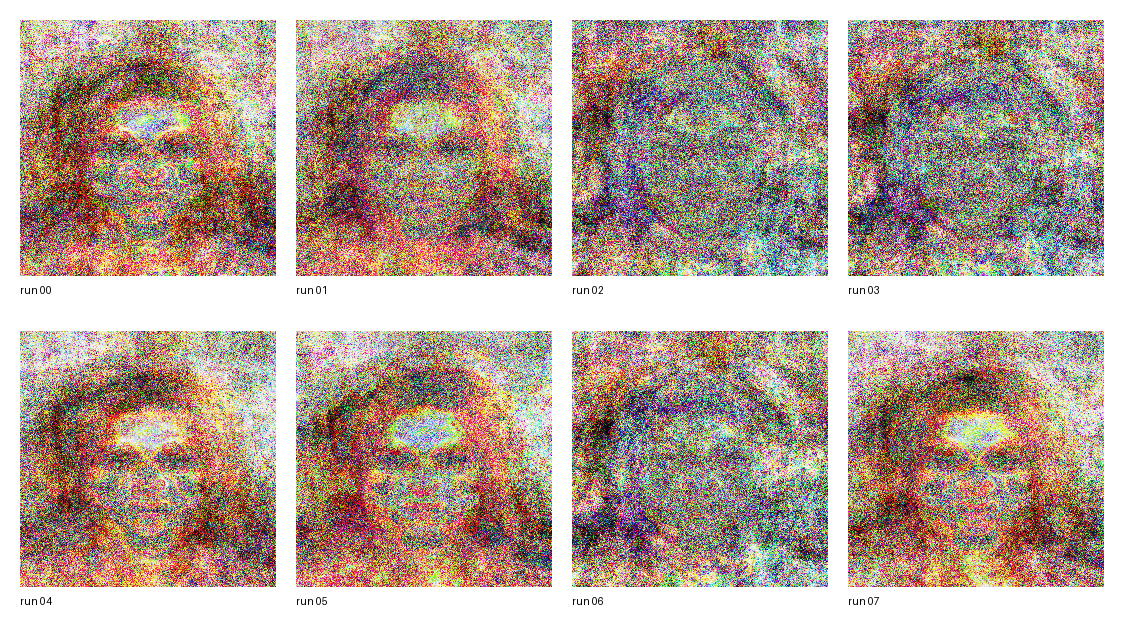


Saved:
/content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion/output/direct_gradient_inversion_contact_sheet.png


In [ ]:
# ============================================================
# CELL 13 — FINAL RECONSTRUCTION CONTACT SHEET
# ============================================================

from PIL import Image, ImageDraw
import math

final_paths = [
    RUNS_ROOT /
    f"run_{i:02d}" /
    "final.png"
    for i in range(N_RESTARTS)
]

for p in final_paths:
    assert p.is_file(), p

thumb = 256
margin = 20
label_h = 35
cols = 4
rows = math.ceil(
    len(final_paths) / cols
)

sheet = Image.new(
    "RGB",
    (
        cols * thumb
        + (cols + 1) * margin,

        rows * (
            thumb
            + label_h
        )
        + (rows + 1) * margin,
    ),
    "white",
)

draw = ImageDraw.Draw(sheet)

for i, path in enumerate(
    final_paths
):

    image = Image.open(
        path
    ).convert("RGB")

    image.thumbnail(
        (thumb, thumb)
    )

    x = (
        margin
        + (i % cols)
        * (
            thumb
            + margin
        )
    )

    y = (
        margin
        + (i // cols)
        * (
            thumb
            + label_h
            + margin
        )
    )

    sheet.paste(
        image,
        (x, y),
    )

    draw.text(
        (
            x,
            y + thumb + 8,
        ),
        f"run {i:02d}",
        fill="black",
    )

CONTACT_SHEET = (
    OUTPUT_ROOT /
    "direct_gradient_inversion_contact_sheet.png"
)

sheet.save(
    CONTACT_SHEET
)

display(sheet)

print()
print("Saved:")
print(CONTACT_SHEET)

### Result

The contact sheet shows the final solutions from all eight random initializations. The outputs contain some coarse face-like structure, particularly in the runs that achieved the strongest gradient matches, but they remain dominated by noisy and distorted pixel patterns rather than reproducing the target image.

This qualitative result agrees with the numerical metrics. Even the runs whose gradients are almost perfectly aligned with the target gradient do not visually recover the target. The important observation is therefore not simply that direct inversion fails to produce a clean face. Instead, it is that *very strong gradient-space agreement can coexist with a substantially different image*.

This makes the direct inversion result relevant to the next diagnostic experiment: the leaked gradient does not appear to provide a unique image-space solution under this reconstruction objective.

## CELL 14: Compare the Final Reconstructions Quantitatively

This final cell loads the aggregated results from the eight random restarts and compares the reconstructions using both gradient-space and pixel-space criteria.

The full table shows the final result of every restart. The first ranking identifies the runs with the smallest relative gradient distance, while the second identifies the runs with the smallest pixel MSE.

This comparison is important because the two rankings need not agree. If the best gradient matches still have substantial pixel error, then the experiment demonstrates the key diagnostic point: *being close to the leaked gradient is not equivalent to recovering the target image*.

In [ ]:
# ============================================================
# CELL 14 — FINAL COMPARISON
# ============================================================

final_df = pd.read_csv(
    OUTPUT_ROOT /
    "final_restart_summary.csv"
)

print("=" * 72)
print("FINAL RESULTS — EXPERIMENT D")
print("=" * 72)

display(
    final_df
)

print()
print("Best gradient match:")
display(
    final_df.sort_values(
        "final_relative_gradient_distance"
    ).head(3)
)

print()
print("Best pixel reconstruction:")
display(
    final_df.sort_values(
        "final_pixel_mse"
    ).head(3)
)

print()
print("Output directory:")
print(OUTPUT_ROOT)

FINAL RESULTS — EXPERIMENT D


,run,seed,runtime_minutes,final_loss,final_gradient_distance,final_relative_gradient_distance,final_gradient_cosine,final_pixel_mse,final_victim_prediction
0,0,3026,0.437315,0.079658,0.374847,0.282238,0.959350,0.458092,0
1,1,3027,0.438751,0.080658,0.377193,0.284004,0.958823,0.462779,0
2,2,3028,0.441761,0.280808,0.703790,0.529913,0.848094,0.633152,0
3,3,3029,0.439802,0.255273,0.671029,0.505246,0.863003,0.621771,0
4,4,3030,0.438959,0.001699,0.054737,0.041214,0.999151,0.431139,0
5,5,3031,0.439021,0.078467,0.372034,0.280120,0.959967,0.456951,0
6,6,3032,0.439474,0.228751,0.635214,0.478279,0.878223,0.611582,0
7,7,3033,0.439264,0.001876,0.057531,0.043318,0.999062,0.451568,0



Best gradient match:


,run,seed,runtime_minutes,final_loss,final_gradient_distance,final_relative_gradient_distance,final_gradient_cosine,final_pixel_mse,final_victim_prediction
4,4,3030,0.438959,0.001699,0.054737,0.041214,0.999151,0.431139,0
7,7,3033,0.439264,0.001876,0.057531,0.043318,0.999062,0.451568,0
5,5,3031,0.439021,0.078467,0.372034,0.280120,0.959967,0.456951,0



Best pixel reconstruction:


,run,seed,runtime_minutes,final_loss,final_gradient_distance,final_relative_gradient_distance,final_gradient_cosine,final_pixel_mse,final_victim_prediction
4,4,3030,0.438959,0.001699,0.054737,0.041214,0.999151,0.431139,0
7,7,3033,0.439264,0.001876,0.057531,0.043318,0.999062,0.451568,0
5,5,3031,0.439021,0.078467,0.372034,0.280120,0.959967,0.456951,0



Output directory:
/content/drive/MyDrive/GGSS_R_experiment_D_direct_gradient_inversion/output


### Result

The final comparison makes the separation between gradient-space and image-space reconstruction explicit.

Runs 4 and 7 are the best gradient matches, with relative gradient distances of `0.041214` and `0.043318` and cosine similarities above `0.999`. They are also the two runs with the lowest pixel MSE among the eight, but their pixel MSEs are still `0.431139` and `0.451568`.

The fact that the best gradient matches also rank best in pixel MSE is encouraging, but the absolute pixel error remains large. More importantly, even an almost exact gradient-direction match does not result in recovery of the target image.

This supports the diagnostic conclusion of Experiment D: *the reconstruction failure is not explained simply by the presence of diffusion in GGSS-R*. When diffusion is removed and the leaked gradient is optimized directly, the candidate can move substantially closer in gradient space without becoming close to the target in image space. The next `gradient_identifiability_diagnosis` experiment can therefore examine this issue more systematically and determine how identifiable the target image is from the leaked gradient itself.